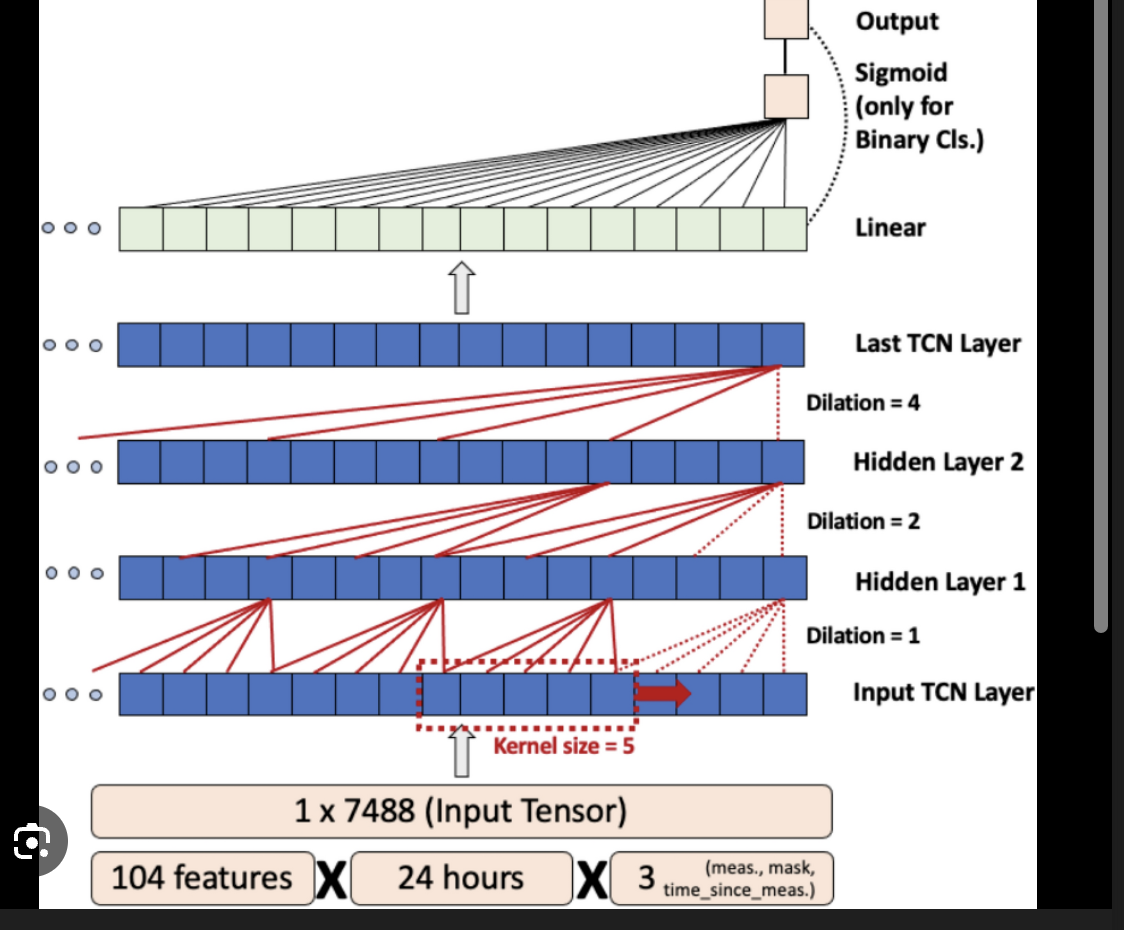

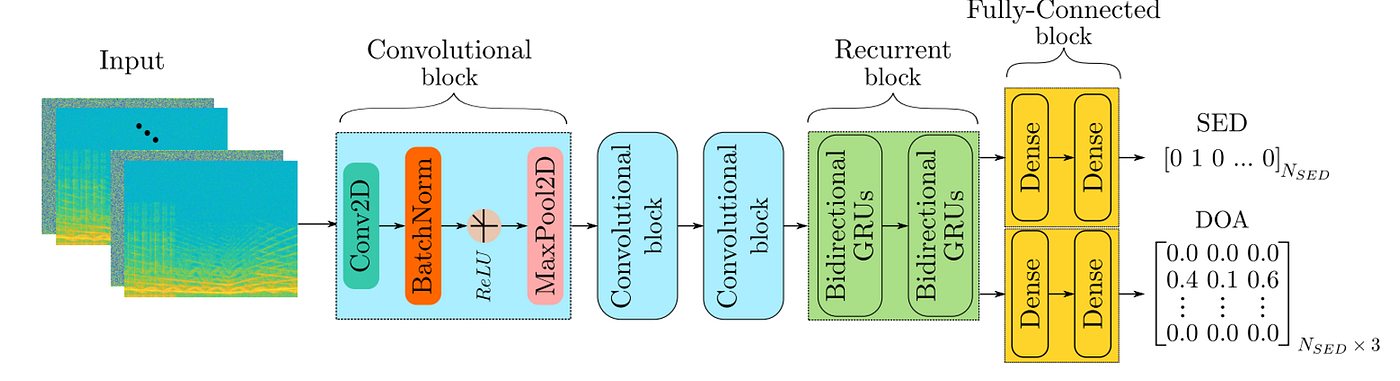

In [1]:
import torch
import torch.nn as nn

class Chomp1d(nn.Module):
    """
    This is the secret sauce for Causal Convolutions in PyTorch.
    It removes the extra elements on the right side of the sequence
    so the output length matches the input length, and causality is maintained.
    """
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        # Slice the tensor to remove the last 'chomp_size' elements along the time dimension
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()

        # --- Layer 1 ---
        # Notice we add padding to both sides, but it's dictated by the dilation
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        # Immediately slice off the right side to make it Causal
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # --- Layer 2 ---
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)

        # --- The Residual Connection ---
        # If the input and output channels don't match, we use a 1x1 conv to align them
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# Example usage:
# A block with dilation 4, padding calculates as (kernel_size-1)*dilation
block = TemporalBlock(n_inputs=16, n_outputs=32, kernel_size=3, stride=1, dilation=4, padding=(3-1)*4)
dummy_time_series = torch.randn(8, 16, 50) # (Batch, Channels, Sequence_Length)
print(f"Output shape: {block(dummy_time_series).shape}") # (8, 32, 50)

Output shape: torch.Size([8, 32, 50])


Football is fundamentally a time-series problem. A goal in the 89th minute isn't just the result of the pass in the 88th minute; it is the culmination of structural shifts, fatigue, and momentum building over the previous 20 minutes of play. LSTMs forget those long-term dependencies. A TCN, with its exponentially expanding receptive field, can mathematically capture exactly how a tackle at $t-16$ influences a shot at $t$.Here is the complete, production-ready PyTorch implementation to build a Football Momentum TCN.

The Data Formulation (The Input Tensor)We need to translate a football match into a 3D tensor: (Batch, Features, Time_Steps).Time Steps ($T$): Let's discretize the match into 90 discrete minutes.Features ($C$): At every minute, we have an array of stats (e.g., Possession %, Number of passes in the final third, Interceptions, Shots on target). Let's say we track 10 distinct features per minute.Our input tensor for one match looks like this: (1, 10, 90).

In [2]:
import torch
import torch.nn as nn

# 1. The Causality Engine
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        # Slices off the future padding to maintain strict causality
        return x[:, :, :-self.chomp_size].contiguous()

# 2. The Core TCN Block
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()

        # Layer 1
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # Layer 2
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)

        # Residual Connection (Matches channel dimensions if they change)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# 3. The Full Momentum Architecture
class FootballMomentumTCN(nn.Module):
    def __init__(self, num_features, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)

        # Build the exponentially dilated stack
        for i in range(num_levels):
            dilation_size = 2 ** i  # Dilation: 1, 2, 4, 8...
            in_channels = num_features if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]

            # The padding formula ensures we have exactly enough zeros to chomp
            padding = (kernel_size - 1) * dilation_size

            layers.append(TemporalBlock(
                n_inputs=in_channels,
                n_outputs=out_channels,
                kernel_size=kernel_size,
                stride=1,
                dilation=dilation_size,
                padding=padding,
                dropout=dropout
            ))

        self.tcn_stack = nn.Sequential(*layers)

        # Final Output Layer: Maps the deep features to a single "Momentum Score" or "Goal Probability"
        self.linear = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        # x shape: (Batch, Features, Sequence_Length)
        y1 = self.tcn_stack(x)

        # We want to output a probability/momentum score at EVERY time step
        # y1 shape is currently (Batch, Channels, Seq_Len)
        # Linear layer expects the feature dimension last, so we transpose
        y1 = y1.transpose(1, 2)

        # raw_logits shape: (Batch, Seq_Len, 1)
        raw_logits = self.linear(y1)

        # Pass through Sigmoid to get a probability between 0 and 1
        momentum_probs = torch.sigmoid(raw_logits)

        return momentum_probs.squeeze(-1) # Output shape: (Batch, Seq_Len)

In [3]:
# 10 match stats per minute (e.g., passes, tackles, possession in final 3rd)
num_match_features = 10

# We will use 4 hidden layers.
# The channel depth increases to capture more abstract representations.
channel_depths = [32, 64, 128, 256]

model = FootballMomentumTCN(
    num_features=num_match_features,
    num_channels=channel_depths,
    kernel_size=3,
    dropout=0.2
)

# Simulate a batch of 4 football matches
# Shape: (4 matches, 10 features, 90 minutes)
simulated_matches = torch.randn(4, 10, 90)

# Calculate momentum
# Because we used `set_to_none=True` equivalent logic in no_grad, it runs fast
with torch.no_grad():
    momentum_scores = model(simulated_matches)

print(f"Input Shape: {simulated_matches.shape}")
print(f"Output Shape: {momentum_scores.shape}")
print(f"Momentum Score for Match 1 at Minute 89: {momentum_scores[0, 89].item():.4f}")

Input Shape: torch.Size([4, 10, 90])
Output Shape: torch.Size([4, 90])
Momentum Score for Match 1 at Minute 89: 0.5116
